# Read ICON-D2 netCDF file

=== Dataset Summary ===
<bound method Dataset.info of <xarray.Dataset> Size: 56MB
Dimensions:                      (init_time: 11817, lead_time: 49)
Coordinates:
  * init_time                    (init_time) datetime64[ns] 95kB 2021-02-10T0...
  * lead_time                    (lead_time) timedelta64[ns] 392B 00:00:00 .....
Data variables:
    precipitation_mean           (init_time, lead_time) float64 5MB ...
    precipitation_min            (init_time, lead_time) float64 5MB ...
    precipitation_max            (init_time, lead_time) float64 5MB ...
    precipitation_stdev          (init_time, lead_time) float64 5MB ...
    temperature_mean             (init_time, lead_time) float64 5MB ...
    air_pressure_sea_level_mean  (init_time, lead_time) float64 5MB ...
    snow_depth_water_eq_mean     (init_time, lead_time) float64 5MB ...
    global_radiation_mean        (init_time, lead_time) float64 5MB ...
    wind_speed_eastward_mean     (init_time, lead_time) float64 5MB ...
    wind_spe

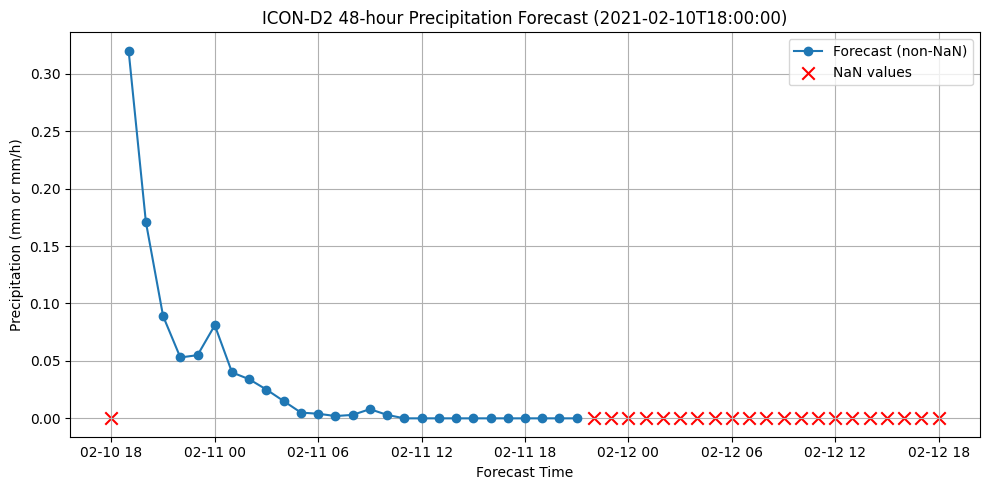

In [ ]:
import xarray as xr
import matplotlib.pyplot as plt
import pandas as pd

file_path = r'C:\Users\qa8171\Desktop\camels_de_1h\CAMELS-DE-1h\forecasts\icond2_deterministic\CAMELS_DE_1h_met_forecast_DE110000.nc'
ds = xr.open_dataset(file_path)

print("=== Dataset Summary ===")
print(ds.info)  # Check the structure of the dataset

print("\n=== Available Variables ===")
for name, var in ds.data_vars.items():
    print(f"- {name:30s} shape={tuple(var.shape)}")

# Select variable (e.g., precipitation mean) ===
var_name = "precipitation_mean"
if var_name not in ds:
    raise ValueError(f"Variable '{var_name}' not found in dataset.")
precip = ds[var_name]

# Select one initialization time (for example, the latest one) ===
# Note: init_time is datetime64, so it can be selected directly
selected_init = precip.init_time[3]  # Latest forecast initialization
print("\nSelected initialization time:", str(selected_init.values))

# Extract forecast series for that initialization time
precip_series = precip.sel(init_time=selected_init)

# Convert to DataFrame for easier plotting ===
df = precip_series.to_dataframe().reset_index()

# Create a forecast time axis = initialization time + lead time
df["forecast_time"] = pd.to_datetime(selected_init.values) + df["lead_time"]

plt.figure(figsize=(10, 5))
plt.plot(df["forecast_time"], df[var_name], marker="o", label="Forecast (non-NaN)")

# Highlight NaN values ===
nan_mask = df[var_name].isna()
if nan_mask.any():
    plt.scatter(
        df.loc[nan_mask, "forecast_time"], 
        [0] * nan_mask.sum(),        # or could use np.nanmean(df[var_name]) if you prefer
        color="red", 
        marker="x", 
        s=80, 
        label="NaN values"
    )

plt.title(f"ICON-D2 48-hour Precipitation Forecast ({str(selected_init.values)[:19]})")
plt.xlabel("Forecast Time")
plt.ylabel("Precipitation (mm)")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()
